In [170]:
import numpy as np
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1) Download dataset
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print("Dataset path:", path)

# 2) IMPORTANT: load with sep=';'
df = pd.read_csv(path + "/student-mat.csv", sep=";")

# 3) clean column names
df.columns = df.columns.str.strip()

df.head(), df.dtypes.head(10)

Using Colab cache for faster access to the 'student-mat-csv' dataset.
Dataset path: /kaggle/input/student-mat-csv


(  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
 0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
 1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
 2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
 3     GP   F   15       U     GT3       T     4     2   health  services  ...   
 4     GP   F   16       U     GT3       T     3     3    other     other  ...   
 
   famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
 0      4        3      4     1     1      3        6   5   6   6  
 1      5        3      3     1     1      3        4   5   5   6  
 2      4        3      2     2     3      3       10   7   8  10  
 3      3        2      2     1     1      5        2  15  14  15  
 4      4        3      2     1     2      5        4   6  10  10  
 
 [5 rows x 33 columns],
 school     object
 sex        object
 age         int64
 address    obj

In [171]:
# Load the student-mat.csv file
df = pd.read_csv(path + "/student-mat.csv")
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [172]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1


In [173]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']
Numerical: []


In [174]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,"school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";1;1;""other"";""other"";""reputation"";""mother"";1;2;2;""yes"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""yes"";3;3;4;2;4;5;2;""8"";""6"";5","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;2;""at_home"";""other"";""reputation"";""mother"";1;1;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";""no"";4;3;1;1;1;2;8;""14"";""13"";13","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""10"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;3;""services"";""services"";""reputation"";""other"";2;3;2;""no"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";4;2;1;2;3;3;8;""10"";""10"";10","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""12"";""12"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""teacher"";""course"";""father"";2;3;2;""no"";""yes"";""no"";""no"";""yes"";""yes"";""yes"";""yes"";4;2;2;2;2;5;0;""12"";""0"";0","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";2;2;""health"";""services"";""reputation"";""mother"";2;2;0;""yes"";""yes"";""yes"";""no"";""yes"";""yes"";""yes"";""no"";4;1;3;1;3;4;2;""8"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";3;1;""other"";""other"";""reputation"";""father"";2;4;0;""no"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";4;4;2;2;3;3;12;""16"";""16"";16","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";3;3;""other"";""health"";""reputation"";""father"";1;4;0;""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";""no"";4;3;3;1;1;4;10;""10"";""11"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";4;3;""services"";""services"";""reputat

In [175]:
print(df.columns.tolist())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [176]:
# Clean column names (remove spaces)
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [177]:
numeric_fix_cols = ["age","Medu","Fedu","traveltime","studytime","failures","absences","G1","G2","G3"]

# keep only columns that actually exist
numeric_fix_cols = [c for c in numeric_fix_cols if c in df.columns]
print("Columns to convert:", numeric_fix_cols)

for col in numeric_fix_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Columns to convert: []


In [178]:
df.columns = df.columns.str.strip()

In [179]:
print(df.columns.tolist())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [180]:
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# IMPORTANT: convert boolean to 0/1
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# now all numeric
numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", len(numerical_cols))
df_encoded.head()

Numeric columns: 394


,"school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";1;1;""other"";""other"";""reputation"";""mother"";1;2;2;""yes"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""yes"";3;3;4;2;4;5;2;""8"";""6"";5","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;2;""at_home"";""other"";""reputation"";""mother"";1;1;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";""no"";4;3;1;1;1;2;8;""14"";""13"";13","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""10"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;3;""services"";""services"";""reputation"";""other"";2;3;2;""no"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";4;2;1;2;3;3;8;""10"";""10"";10","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""12"";""12"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""teacher"";""course"";""father"";2;3;2;""no"";""yes"";""no"";""no"";""yes"";""yes"";""yes"";""yes"";4;2;2;2;2;5;0;""12"";""0"";0","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";2;2;""health"";""services"";""reputation"";""mother"";2;2;0;""yes"";""yes"";""yes"";""no"";""yes"";""yes"";""yes"";""no"";4;1;3;1;3;4;2;""8"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";3;1;""other"";""other"";""reputation"";""father"";2;4;0;""no"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";4;4;2;2;3;3;12;""16"";""16"";16","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";3;3;""other"";""health"";""reputation"";""father"";1;4;0;""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";""no"";4;3;3;1;1;4;10;""10"";""11"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";4;3;""services"";""services"";""reputat

In [181]:
scaler = StandardScaler()
df_processed = pd.DataFrame(
    scaler.fit_transform(df_encoded[numerical_cols]),
    columns=numerical_cols
)
df_processed.head()

,"school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";1;1;""other"";""other"";""reputation"";""mother"";1;2;2;""yes"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""yes"";3;3;4;2;4;5;2;""8"";""6"";5","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;2;""at_home"";""other"";""reputation"";""mother"";1;1;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";""no"";4;3;1;1;1;2;8;""14"";""13"";13","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""10"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;3;""services"";""services"";""reputation"";""other"";2;3;2;""no"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";4;2;1;2;3;3;8;""10"";""10"";10","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""12"";""12"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""teacher"";""course"";""father"";2;3;2;""no"";""yes"";""no"";""no"";""yes"";""yes"";""yes"";""yes"";4;2;2;2;2;5;0;""12"";""0"";0","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";2;2;""health"";""services"";""reputation"";""mother"";2;2;0;""yes"";""yes"";""yes"";""no"";""yes"";""yes"";""yes"";""no"";4;1;3;1;3;4;2;""8"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";3;1;""other"";""other"";""reputation"";""father"";2;4;0;""no"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";4;4;2;2;3;3;12;""16"";""16"";16","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";3;3;""other"";""health"";""reputation"";""father"";1;4;0;""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";""no"";4;3;3;1;1;4;10;""10"";""11"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";4;3;""services"";""services"";""reputat

In [182]:
# If you only have df_encoded (after get_dummies), build df_processed like this:
import numpy as np
from sklearn.preprocessing import StandardScaler

# convert bool to int if exists
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
df_processed = pd.DataFrame(
    scaler.fit_transform(df_encoded[numeric_cols]),
    columns=numeric_cols
)

df_processed.head()

,"school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";1;1;""other"";""other"";""reputation"";""mother"";1;2;2;""yes"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""yes"";3;3;4;2;4;5;2;""8"";""6"";5","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;2;""at_home"";""other"";""reputation"";""mother"";1;1;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";""no"";4;3;1;1;1;2;8;""14"";""13"";13","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";2;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""10"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;3;""services"";""services"";""reputation"";""other"";2;3;2;""no"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";4;2;1;2;3;3;8;""10"";""10"";10","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""health"";""course"";""mother"";1;3;0;""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""yes"";""no"";4;3;2;1;1;5;2;""12"";""12"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""GT3"";""T"";3;4;""services"";""teacher"";""course"";""father"";2;3;2;""no"";""yes"";""no"";""no"";""yes"";""yes"";""yes"";""yes"";4;2;2;2;2;5;0;""12"";""0"";0","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";2;2;""health"";""services"";""reputation"";""mother"";2;2;0;""yes"";""yes"";""yes"";""no"";""yes"";""yes"";""yes"";""no"";4;1;3;1;3;4;2;""8"";""9"";8","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""R"";""LE3"";""T"";3;1;""other"";""other"";""reputation"";""father"";2;4;0;""no"";""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";4;4;2;2;3;3;12;""16"";""16"";16","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";3;3;""other"";""health"";""reputation"";""father"";1;4;0;""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";""no"";4;3;3;1;1;4;10;""10"";""11"";11","school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3_GP;""F"";15;""U"";""GT3"";""A"";4;3;""services"";""services"";""reputat

In [183]:
# Reload correctly (IMPORTANT: sep=';')
df = pd.read_csv(path + "/student-mat.csv", sep=";")
df.columns = df.columns.str.strip()

print(df.columns.tolist())
print("G3 in df?", "G3" in df.columns)
df.head()

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
G3 in df? True


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [184]:
# One-hot encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert bool to int if exists
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Scale numeric columns (now everything should be numeric)
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
df_processed = pd.DataFrame(
    scaler.fit_transform(df_encoded[numeric_cols]),
    columns=numeric_cols
)

print("G3 in df_processed?", "G3" in df_processed.columns)
df_processed.head()

G3 in df_processed? True


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,0.668496,-0.296908,2.597133,-1.257656,-0.919671,-1.017881,0.507899,0.23094,-2.232677,-0.708450
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,-1.495896,-0.296908,-0.385040,0.795130,-0.919671,-1.017881,-1.968894,0.23094,0.447893,-0.708450
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,0.668496,-0.296908,2.597133,-1.257656,1.087346,-1.017881,0.507899,0.23094,0.447893,-0.708450
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,0.668496,-0.296908,-0.385040,0.795130,1.087346,0.982433,0.507899,0.23094,0.447893,1.411533
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,-1.495896,-0.296908,-0.385040,0.795130,1.087346,-1.017881,0.507899,0.23094,-2.232677,-0.708450


In [185]:
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred = lin.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.2701812023259871
R²: 0.7241341236974019


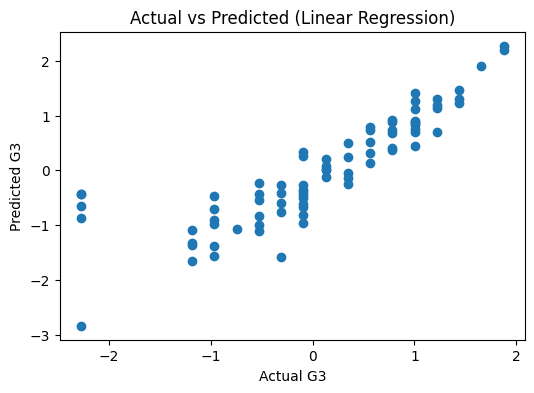

In [186]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [187]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "SVR (RBF)": SVR(kernel="rbf"),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append([name, mean_squared_error(y_test, preds), r2_score(y_test, preds)])

pd.DataFrame(results, columns=["Model", "MSE", "R²"]).sort_values("R²", ascending=False)

,Model,MSE,R²
4,Random Forest,0.184575,0.811541
5,Gradient Boosting,0.191494,0.804477
2,Lasso,0.267079,0.727301
1,Ridge,0.269595,0.724732
0,Linear Regression,0.270181,0.724134
3,SVR (RBF),0.278018,0.716132


In [188]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print("CV mean R²:", cv_scores.mean(), "| std:", cv_scores.std())

CV mean R²: 0.7842465150674718 | std: 0.060526373782248004


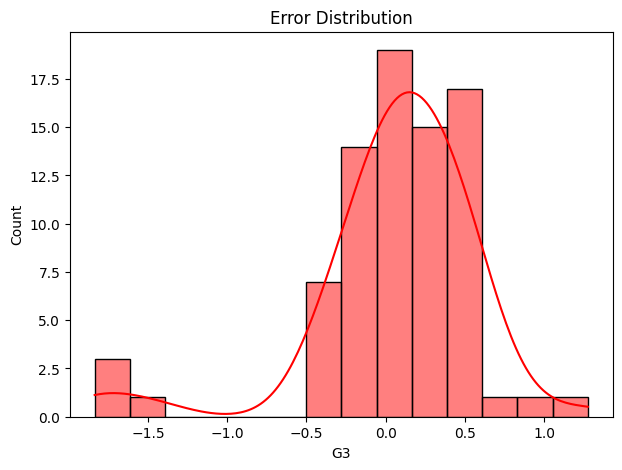

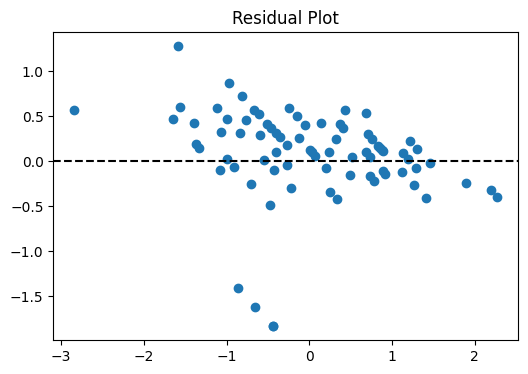

In [189]:
errors = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(errors, kde=True, color="red")
plt.title("Error Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred, errors)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residual Plot")
plt.show()

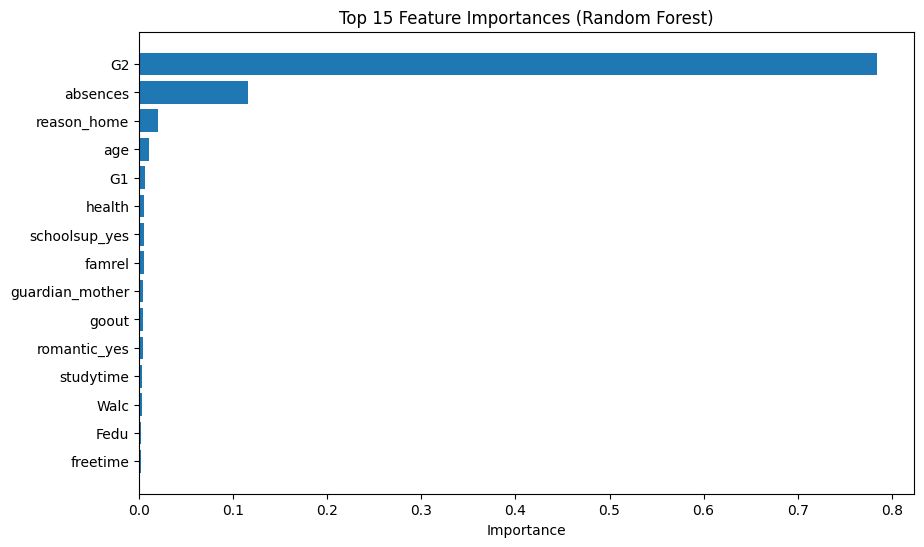

In [190]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-15:]

plt.figure(figsize=(10,6))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.yticks(range(len(top_idx)), X.columns[top_idx])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()